In [88]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

In [56]:
data  = pd.read_csv('titanic.csv')

In [57]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [58]:
data.drop(columns=['PassengerId' ,'Name', 'Ticket' ] , inplace=True)

In [59]:
data.drop(columns=['Cabin' ] , inplace=True)

In [60]:
data.drop(columns=['Embarked' ] , inplace=True)

In [61]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
dtypes: float64(2), int64(4), object(1)
memory usage: 48.9+ KB


In [62]:
data['Sex'].unique()

array(['male', 'female'], dtype=object)

In [63]:
data['Sex'] = data['Sex'].map({
    'male' : 1,
    'female' : 0
})

In [64]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
dtypes: float64(2), int64(5)
memory usage: 48.9 KB


In [65]:
data['Age'] = data['Age'].fillna(data['Age'].median())

In [66]:
data.isna().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
dtype: int64

In [67]:
corr = data.corr()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.543351,-0.064910,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,0.131900,-0.339898,0.083081,0.018443,-0.549500
Sex,-0.543351,0.131900,1.000000,0.081163,-0.114631,-0.245489,-0.182333
Age,-0.064910,-0.339898,0.081163,1.000000,-0.233296,-0.172482,0.096688
SibSp,-0.035322,0.083081,-0.114631,-0.233296,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.245489,-0.172482,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,-0.182333,0.096688,0.159651,0.216225,1.000000


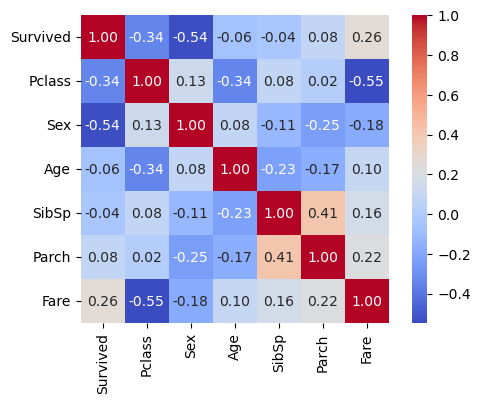

In [72]:
plt.figure(figsize=(6,4))

sns.heatmap(corr , annot=True , cmap='coolwarm' , square=True , fmt='.2f' , linecolor='black' )
plt.show()

In [75]:
round(corr['Survived'].sort_values(ascending=False),2)

Survived    1.00
Fare        0.26
Parch       0.08
SibSp      -0.04
Age        -0.06
Pclass     -0.34
Sex        -0.54
Name: Survived, dtype: float64

In [76]:
# sex and pascal are only related columns with target variable 
# columns selected  = pclass , fare , sex , age

In [78]:
data = data.drop(columns=['Parch' ,'SibSp', ])

In [79]:
data

,Survived,Pclass,Sex,Age,Fare
0,0,3,1,22.0,7.2500
1,1,1,0,38.0,71.2833
2,1,3,0,26.0,7.9250
3,1,1,0,35.0,53.1000
4,0,3,1,35.0,8.0500
...,...,...,...,...,...
886,0,2,1,27.0,13.0000
887,1,1,0,19.0,30.0000
888,0,3,0,28.0,23.4500
889,1,1,1,26.0,30.0000


In [80]:
x = data.drop(columns=['Survived'])
y = data['Survived']

In [83]:
x_train , x_test ,y_train , y_test = train_test_split(x,y,stratify=y,random_state=42,test_size=0.2)
x_train.shape , x_test.shape ,y_train.shape , y_test.shape 

((712, 4), (179, 4), (712,), (179,))

In [89]:
model = DecisionTreeClassifier()

model.fit(x_train,y_train)

y_pred = model.predict(x_test)

In [94]:
print(classification_report(y_test , y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       110
           1       1.00      1.00      1.00        69

    accuracy                           1.00       179
   macro avg       1.00      1.00      1.00       179
weighted avg       1.00      1.00      1.00       179



In [95]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 3, 5, 7, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": [None, "sqrt", "log2"]
}

model_cv = GridSearchCV(estimator=DecisionTreeClassifier(), param_grid=param_grid ,cv=5)

In [96]:
model_cv.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 3, 5, 7, 10],
                         'max_features': [None, 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]})

In [97]:
model_cv.best_estimator_

DecisionTreeClassifier(criterion='entropy', max_depth=7, max_features='sqrt',
                       min_samples_leaf=4, min_samples_split=5)

In [98]:
model2  = DecisionTreeClassifier(criterion='entropy', max_depth=7, max_features='sqrt',min_samples_leaf=4, min_samples_split=5)
model2.fit(x_train ,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=7, max_features='sqrt',
                       min_samples_leaf=4, min_samples_split=5)

In [99]:
y_pred2 = model2.predict(x_test)

In [100]:
print(classification_report(y_test , y_pred2))

              precision    recall  f1-score   support

           0       0.76      0.90      0.82       110
           1       0.78      0.55      0.64        69

    accuracy                           0.77       179
   macro avg       0.77      0.73      0.73       179
weighted avg       0.77      0.77      0.76       179



In [102]:
print(model2.score(x_train , y_train))

0.8469101123595506
